To analyze the differences in named entity recognition (NER) between the two organizations' sustainability communication texts, we'll utilize Python along with several natural language processing (NLP) libraries such as NLTK and spaCy. This process involves importing the text data, cleaning and preprocessing it (including tokenization and normalization), and then applying NER to extract and compare entities mentioned by each organization.

In [1]:
# Import necessary libraries
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy

# Download NLTK data files (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

First, we'll import the text data from the two organizations. Assuming the texts are stored in two separate text files named `organization1.txt` and `organization2.txt`, we'll read them into Python strings for processing.

In [2]:
# Read the text data from two organizations
with open('organization1.txt', 'r', encoding='utf-8') as file:
    org1_text = file.read()

with open('organization2.txt', 'r', encoding='utf-8') as file:
    org2_text = file.read()

Next, we need to clean the data to remove any unwanted characters, numbers, and punctuations. We'll also convert the text to lowercase to ensure consistency during analysis.

In [3]:
import re

def clean_text(text):
    # Remove unwanted characters, numbers, and punctuations
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert text to lowercase
    text = text.lower()
    return text

org1_clean = clean_text(org1_text)
org2_clean = clean_text(org2_text)

After cleaning, we'll tokenize the text, which involves splitting the text into individual words or tokens. Tokenization is a crucial step in NLP as it prepares the text for further processing.

In [4]:
# Tokenize the texts
org1_tokens = word_tokenize(org1_clean)
org2_tokens = word_tokenize(org2_clean)

To refine our dataset, we'll remove stopwords—common words that may not contribute significantly to the analysis, such as "the," "and," or "is." This step helps in focusing on the more meaningful words in the texts.

In [5]:
# Remove stopwords
stop_words = set(stopwords.words('english'))
org1_tokens_nostop = [word for word in org1_tokens if word not in stop_words]
org2_tokens_nostop = [word for word in org2_tokens if word not in stop_words]

Text normalization also includes lemmatization, which reduces words to their base or dictionary form. We'll use spaCy for lemmatization, which will help in treating different forms of a word as a single item.

In [6]:
# Load spaCy's English model
nlp = spacy.load('en_core_web_sm')

# Lemmatize the tokens
def lemmatize_tokens(tokens):
    doc = nlp(' '.join(tokens))
    return [token.lemma_ for token in doc]

org1_lemmatized = lemmatize_tokens(org1_tokens_nostop)
org2_lemmatized = lemmatize_tokens(org2_tokens_nostop)

With the text cleaned and normalized, we can now perform named entity recognition using spaCy's NER capabilities. This will allow us to extract entities like organizations, locations, and person names mentioned in the texts.

In [7]:
# Perform NER on the original cleaned text (not token lists)
org1_doc = nlp(org1_clean)
org2_doc = nlp(org2_clean)

# Extract entities
org1_entities = [(ent.text, ent.label_) for ent in org1_doc.ents]
org2_entities = [(ent.text, ent.label_) for ent in org2_doc.ents]

We can analyze the extracted entities by counting the frequency of different entity types or specific entities. This will help us understand which entities are emphasized by each organization.

In [8]:
from collections import Counter

# Count entity labels
org1_entity_counts = Counter([label for text, label in org1_entities])
org2_entity_counts = Counter([label for text, label in org2_entities])

print("Organization 1 Entity Counts:", org1_entity_counts)
print("Organization 2 Entity Counts:", org2_entity_counts)

Organization 1 Entity Counts: Counter({'GPE': 12, 'CARDINAL': 11, 'QUANTITY': 10, 'DATE': 9, 'ORG': 7, 'LOC': 3, 'NORP': 2, 'PERSON': 2, 'PERCENT': 1})
Organization 2 Entity Counts: Counter({'DATE': 34, 'PERSON': 25, 'CARDINAL': 22, 'GPE': 20, 'ORG': 17, 'NORP': 10, 'LOC': 3, 'ORDINAL': 3, 'QUANTITY': 1, 'TIME': 1})


To visualize the differences between the organizations, we'll create dataframes and plot the distribution of entity types using matplotlib. Visual representations can provide clearer insights into the data.

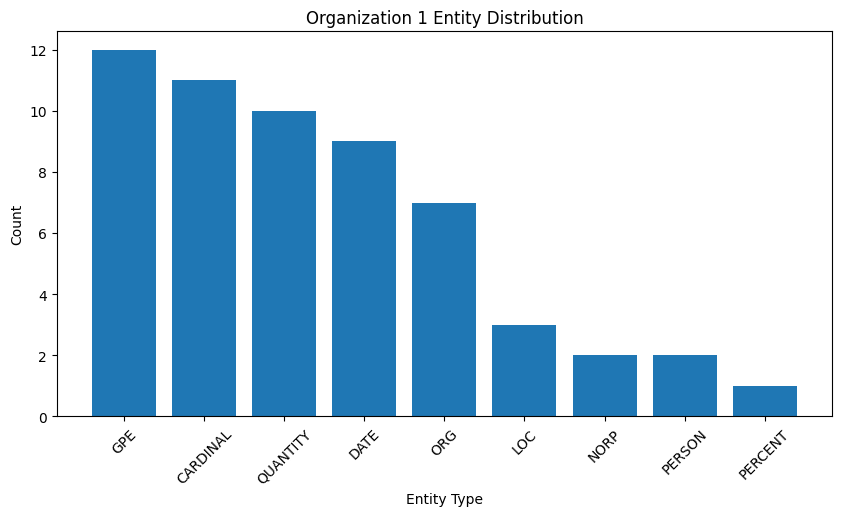

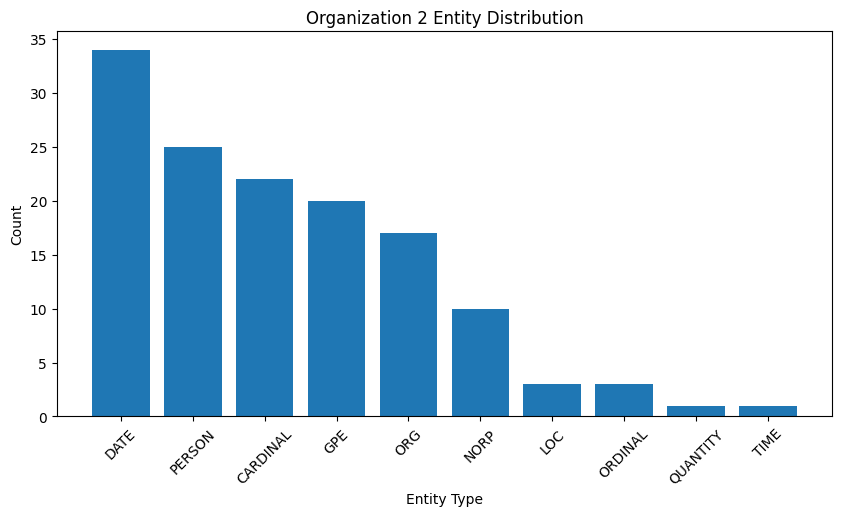

In [10]:
import matplotlib.pyplot as plt

# Create DataFrames
org1_entity_df = pd.DataFrame(org1_entities, columns=['Entity', 'Label'])
org2_entity_df = pd.DataFrame(org2_entities, columns=['Entity', 'Label'])

# Plot entity counts for Organization 1
org1_entity_counts_df = org1_entity_df['Label'].value_counts().reset_index()
# Rename the columns explicitly
org1_entity_counts_df.columns = ['Entity Type', 'Count']
plt.figure(figsize=(10,5))
plt.bar(org1_entity_counts_df['Entity Type'], org1_entity_counts_df['Count'])
plt.title('Organization 1 Entity Distribution')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Plot entity counts for Organization 2
org2_entity_counts_df = org2_entity_df['Label'].value_counts().reset_index()
# Rename the columns explicitly
org2_entity_counts_df.columns = ['Entity Type', 'Count']
plt.figure(figsize=(10,5))
plt.bar(org2_entity_counts_df['Entity Type'], org2_entity_counts_df['Count'])
plt.title('Organization 2 Entity Distribution')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


By comparing the entity distributions, we can identify unique entities and entity types that are prevalent in each organization's communication. This can highlight differences in focus areas or communication strategies regarding sustainability.

In [11]:
# Identify unique entities for each organization
org1_unique_entities = set(org1_entity_df['Entity']) - set(org2_entity_df['Entity'])
org2_unique_entities = set(org2_entity_df['Entity']) - set(org1_entity_df['Entity'])

print("Unique entities in Organization 1:", org1_unique_entities)
print("Unique entities in Organization 2:", org2_unique_entities)

Unique entities in Organization 1: {'the target  \n\nyear', 'about  million cubic meters', 'billions', 'northern europe', 'approximately  tons', 'paris', 'million', 'the base year', 'the base year  the', 'tommy johansson', 'about  cubic meters', 'half a million tons', 'at least  million', 'million cubic meters', 'almost three years', 'jan', 'the first half', 'around  million tons', 'hpu', 'about  million tons', 'million tons', 'gat', 'stockholm  \n\ntfn', 'sweden', 'more than half', 'approximately  percent', 'annually', 'academia research institutes  \n\n', 'the north sea', 'an additional   \n\nmillion cubic meters', 'norway', 'gothenburg', 'one cubic meter', 'around  tons'}
Unique entities in Organization 2: {'the constructive institute', 'gustafsson', 'mark lee hunter  \n\n', 'earlier this month', 'bloomberg  \n\ngreen ammonia', 'cherelle jackson', 'netherlands', 'a century ago', 'tom brookes', 'more than one', 'france', 'nacelle  \n\ncanopies', 'agence france', 'panama', 'stockholm 

Finally, we can delve deeper into the context in which these entities are mentioned by examining the sentences or paragraphs surrounding them. This qualitative analysis complements the quantitative data and provides a comprehensive understanding of each organization's approach to sustainability communication.

In [12]:
# Function to extract sentences containing unique entities
def extract_sentences(text, entities):
    sentences = []
    doc = nlp(text)
    for sent in doc.sents:
        for entity in entities:
            if entity in sent.text:
                sentences.append(sent.text)
                break
    return sentences

org1_sentences = extract_sentences(org1_text, org1_unique_entities)
org2_sentences = extract_sentences(org2_text, org2_unique_entities)

print("Sample sentences from Organization 1:")
for sentence in org1_sentences[:5]:
    print("-", sentence)

print("\nSample sentences from Organization 2:")
for sentence in org2_sentences[:5]:
    print("-", sentence)

Sample sentences from Organization 1:
- Tests have been  

conducted with good results, and the plan is to establish full-  

scale plants in the late 2020s.  

1 of 8  

10/10/24, 15:46  

Page 2

Carbon Capture and Storage | Preem   

https://www.preem.com/en/about-us/projects/carbon-capture/  

The "Preem CCS" pilot project has analyzed everything from capturing to  

storing carbon dioxide for almost three years.
- How much can carbon emissions be reduced  

Carbon dioxide emissions in Sweden are currently around 50 million tons per  

year.
- If you also include emissions from biogenic sources, the total emissions  

are about 70 million tons per year.  


- By introducing carbon capture at the 27 Swedish industrial plants that  

generate more than half a million tons per year, emissions could be reduced  

by 23 million tons, of which 14 million tons are of fossil origin.  


- This technology is expected to reduce Preem's carbon dioxide  

emissions by half a million tons annua

By following these steps, we've cleaned, processed, and structured the text data from both organizations. The named entity recognition analysis has provided insights into the differences in their sustainability communications, highlighting unique entities and focal points for each organization.